# NASDAQ-100 Minute Bars - Exploratory Data Analysis

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

This notebook provides a comprehensive exploration of the AlgoSeek TAQ minute bar dataset.
Unlike simple OHLCV data, TAQ bars contain 61 pre-computed columns that capture the
full microstructure of each trading minute: quote dynamics, trade execution, aggressor
behavior, and liquidity conditions.

## Learning Objectives

After completing this notebook, you will be able to:
- Load and validate TAQ minute bars using the canonical loader
- Understand the schema: quote-derived vs trade-derived columns
- Interpret null patterns (bars with no trades are normal, not errors)
- Analyze trade bucket fields to measure aggressor behavior
- Interpret pressure and tick direction indicators
- Distinguish exchange volume from off-exchange (FINRA) activity
- Connect spread dynamics to liquidity conditions

## Dataset Overview

| Attribute | Value |
|-----------|-------|
| **Source** | AlgoSeek TAQ Minute Bars |
| **Coverage** | NASDAQ-100 constituents |
| **Period** | 2020-2021 |
| **Frequency** | 1-minute bars (continuous, 04:00-20:00 ET) |
| **Columns** | 61 pre-computed microstructure fields |

## Book reference

Section §3.2, *The Anatomy of Modern Market Data Feeds* — AlgoSeek
minute-bars bullet (61 pre-computed microstructure columns serving as
input for Chapter 7 feature engineering).

## Prerequisites

- AlgoSeek TAQ minute bars under
  `data/equities/nasdaq100/minute_bars/year=YYYY/month=MM.parquet` (Hive
  partitioned). Loaded via `load_nasdaq100_bars`.
- Companion: `11_algoseek_taq_eda` for the underlying tick-level stream
  these bars summarize.

In [1]:
"""NASDAQ-100 Minute Bars EDA — exploring AlgoSeek TAQ minute bar microstructure fields."""

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from data import load_nasdaq100_bars
from utils.data_quality import check_ohlc_invariants, describe_coverage, null_rate, per_asset_stats
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
# Always limit data to avoid OOM (full NASDAQ-100 is ~50M rows)
MAX_SYMBOLS = 10
END_DATE = "2020-12-31"

In [3]:
# Select top N tickers by market cap
_ALL_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "GOOG", "AVGO", "COST"]
SAMPLE_TICKERS = _ALL_TICKERS[:MAX_SYMBOLS]

print(f"Tickers: {len(SAMPLE_TICKERS)}")

Tickers: 10


## 1. Load and Inspect

The NASDAQ-100 minute bars are stored in Hive-partitioned Parquet files:
`equities/nasdaq100/minute_bars/year={YYYY}/month={MM}.parquet`

In [4]:
# Load data with all microstructure columns
# Limit to 2020 to avoid OOM (full 2020-2021 x 100 symbols is ~50M rows)
df = load_nasdaq100_bars(
    symbols=SAMPLE_TICKERS,
    start_date="2020-01-01",
    end_date=END_DATE,
    include_microstructure=True,
)

print("=== NASDAQ-100 Minute Bars ===")
print(f"Shape: {df.shape}")
print(f"Symbols: {df['symbol'].n_unique()}")
print(f"Memory: {df.estimated_size('mb'):.1f} MB")

=== NASDAQ-100 Minute Bars ===
Shape: (2182083, 63)
Symbols: 9
Memory: 1208.4 MB


### Schema Overview

TAQ minute bars contain 61 columns organized into distinct families based on
the underlying market mechanism they measure.

In [5]:
# Full schema
print("\n=== Schema (All 61 Columns) ===")
for i, (col, dtype) in enumerate(df.schema.items()):
    print(f"  {i + 1:2d}. {col}: {dtype}")


=== Schema (All 61 Columns) ===
   1. date: Date
   2. symbol: String
   3. time: String
   4. open_bar_time: String
   5. open_bid_price: Float64
   6. open_bid_size: Int64
   7. open_ask_price: Float64
   8. open_ask_size: Int64
   9. first_trade_time: String
  10. first_trade_price: Float64
  11. first_trade_size: Int64
  12. high_bid_time: String
  13. high_bid_price: Float64
  14. high_bid_size: Int64
  15. high_ask_time: String
  16. high_ask_price: Float64
  17. high_ask_size: Int64
  18. high_trade_time: String
  19. high_trade_price: Float64
  20. high_trade_size: Int64
  21. low_bid_time: String
  22. low_bid_price: Float64
  23. low_bid_size: Int64
  24. low_ask_time: String
  25. low_ask_price: Float64
  26. low_ask_size: Int64
  27. low_trade_time: String
  28. low_trade_price: Float64
  29. low_trade_size: Int64
  30. close_bar_time: String
  31. close_bid_price: Float64
  32. close_bid_size: Int64
  33. close_ask_price: Float64
  34. close_ask_size: Int64
  35. last_tra

### Column Families

The 61 columns can be grouped into 7 families based on what they measure:

| Family | Columns | What They Measure |
|--------|---------|-------------------|
| **Identifiers** | date, symbol, time, timestamp | Row keys |
| **Quote OHLC** | open/high/low/close_bid/ask_price/size/time | NBBO dynamics |
| **Trade OHLC** | first/high/low/last_trade_price/size/time | Actual executions |
| **Spread** | min_spread, max_spread | Bid-ask spread range |
| **Volume** | volume, finra_volume, total_trades | Exchange vs off-exchange |
| **Trade Buckets** | trade_at_bid/mid/ask, trade_at_cross | Aggressor direction |
| **Pressure** | trade_to_mid_vol_weight, uptick/downtick_volume | Directional intensity |

In [6]:
# Column families — quote OHLC
COLUMN_FAMILIES = {
    "Identifiers": ["date", "symbol", "time", "timestamp", "year", "month"],
    "Quote OHLC (Prices)": [
        "open_bid_price",
        "open_ask_price",
        "high_bid_price",
        "high_ask_price",
        "low_bid_price",
        "low_ask_price",
        "close_bid_price",
        "close_ask_price",
    ],
    "Quote OHLC (Sizes)": [
        "open_bid_size",
        "open_ask_size",
        "high_bid_size",
        "high_ask_size",
        "low_bid_size",
        "low_ask_size",
        "close_bid_size",
        "close_ask_size",
    ],
    "Quote OHLC (Times)": [
        "open_bar_time",
        "high_bid_time",
        "high_ask_time",
        "low_bid_time",
        "low_ask_time",
        "close_bar_time",
    ],
}

In [7]:
# Column families — trade OHLC
COLUMN_FAMILIES.update(
    {
        "Trade OHLC": [
            "first_trade_price",
            "first_trade_size",
            "first_trade_time",
            "high_trade_price",
            "high_trade_size",
            "high_trade_time",
            "low_trade_price",
            "low_trade_size",
            "low_trade_time",
            "last_trade_price",
            "last_trade_size",
            "last_trade_time",
        ],
        "Spread": ["min_spread", "max_spread"],
        "Volume": ["volume", "finra_volume", "total_trades", "cancel_size"],
    }
)

In [8]:
# Column families — order flow and pressure indicators
COLUMN_FAMILIES.update(
    {
        "Trade Buckets": [
            "trade_at_bid",
            "trade_at_bid_mid",
            "trade_at_mid",
            "trade_at_mid_ask",
            "trade_at_ask",
            "trade_at_cross",
        ],
        "Tick Direction": [
            "uptick_volume",
            "downtick_volume",
            "repeat_uptick_volume",
            "repeat_downtick_volume",
            "unknown_tick_volume",
        ],
        "Pressure & VWAP": [
            "vwap",
            "finra_vwap",
            "trade_to_mid_vol_weight",
            "trade_to_mid_vol_weight_rel",
            "time_weight_bid",
            "time_weight_ask",
        ],
        "Quote Count": ["nbbo_quote_count"],
    }
)

In [9]:
print("\n=== Column Families ===")
for family, cols in COLUMN_FAMILIES.items():
    available = [c for c in cols if c in df.columns]
    print(f"  {family}: {len(available)}/{len(cols)} columns")


=== Column Families ===
  Identifiers: 5/6 columns
  Quote OHLC (Prices): 8/8 columns
  Quote OHLC (Sizes): 8/8 columns
  Quote OHLC (Times): 6/6 columns
  Trade OHLC: 12/12 columns
  Spread: 2/2 columns
  Volume: 4/4 columns
  Trade Buckets: 6/6 columns
  Tick Direction: 5/5 columns
  Pressure & VWAP: 6/6 columns
  Quote Count: 1/1 columns


## 2. Coverage Summary

TAQ minute bars are **continuous**: a row exists for every minute from 04:00 ET
to 20:00 ET, even when no trades occur. This is different from tick data where
rows only exist when events happen.

In [10]:
# Overall coverage
cov = describe_coverage(df, time_col="timestamp", asset_col="symbol")
print("=== Coverage ===")
print(f"  Total rows: {cov['rows']:,}")
print(f"  Symbols: {cov['assets']}")
print(f"  Time range: {cov['time_min']} to {cov['time_max']}")
print(f"  Unique timestamps: {cov['unique_times']:,}")

=== Coverage ===
  Total rows: 2,182,083
  Symbols: 9
  Time range: 2020-01-02 04:00:00 to 2020-12-31 19:59:00
  Unique timestamps: 242,520


In [11]:
# Per-symbol statistics
symbol_stats = per_asset_stats(
    df,
    time_col="timestamp",
    asset_col="symbol",
    price_col="last_trade_price",
    volume_col="volume",
)

print("\nPer-Symbol Statistics:")
print(symbol_stats)


Per-Symbol Statistics:
shape: (9, 6)
┌────────┬────────┬─────────────────────┬─────────────────────┬─────────────┬──────────────┐
│ symbol ┆ rows   ┆ start               ┆ end                 ┆ avg_price   ┆ avg_volume   │
│ ---    ┆ ---    ┆ ---                 ┆ ---                 ┆ ---         ┆ ---          │
│ str    ┆ u32    ┆ datetime[μs]        ┆ datetime[μs]        ┆ f64         ┆ f64          │
╞════════╪════════╪═════════════════════╪═════════════════════╪═════════════╪══════════════╡
│ AAPL   ┆ 242520 ┆ 2020-01-02 04:00:00 ┆ 2020-12-31 19:59:00 ┆ 258.018227  ┆ 38812.976018 │
│ AMZN   ┆ 242520 ┆ 2020-01-02 04:00:00 ┆ 2020-12-31 19:59:00 ┆ 2692.437639 ┆ 3079.970506  │
│ AVGO   ┆ 242131 ┆ 2020-01-02 04:00:00 ┆ 2020-12-31 19:59:00 ┆ 320.70053   ┆ 1673.335694  │
│ COST   ┆ 242335 ┆ 2020-01-02 04:00:00 ┆ 2020-12-31 19:58:00 ┆ 329.923306  ┆ 1828.943636  │
│ GOOG   ┆ 242504 ┆ 2020-01-02 04:00:00 ┆ 2020-12-31 19:59:00 ┆ 1475.148803 ┆ 1306.065896  │
│ GOOGL  ┆ 242515 ┆ 2020-01-02 0

In [12]:
# Trading hours breakdown
# TAQ bars cover extended hours: 04:00-09:30 (pre), 09:30-16:00 (RTH), 16:00-20:00 (post)
df_hours = df.with_columns(pl.col("timestamp").dt.hour().alias("hour"))

hours_dist = (
    df_hours.group_by("hour")
    .agg(pl.len().alias("bars"), pl.col("volume").sum().alias("total_volume"))
    .sort("hour")
)

print("\n=== Bars by Hour (Sample) ===")
print(hours_dist.filter(pl.col("hour").is_in([4, 9, 10, 12, 15, 16, 19])))


=== Bars by Hour (Sample) ===
shape: (7, 3)
┌──────┬────────┬──────────────┐
│ hour ┆ bars   ┆ total_volume │
│ ---  ┆ ---    ┆ ---          │
│ i8   ┆ u32    ┆ i64          │
╞══════╪════════╪══════════════╡
│ 4    ┆ 136620 ┆ 33328414     │
│ 9    ┆ 136620 ┆ 3706652805   │
│ 10   ┆ 136620 ┆ 3322075683   │
│ 12   ┆ 136620 ┆ 1963088343   │
│ 15   ┆ 136620 ┆ 4055958089   │
│ 16   ┆ 136620 ┆ 2815449716   │
│ 19   ┆ 134943 ┆ 55946770     │
└──────┴────────┴──────────────┘


## 3. Null Patterns: Semantic, Not Errors

TAQ minute bars have two types of columns with different null semantics:

| Column Type | When Null | Meaning |
|-------------|-----------|---------|
| **Quote fields** | Rarely | No quote activity (very rare) |
| **Trade fields** | Frequently | No trades in this minute bar |

Null trade fields are NOT missing data - they correctly indicate "no trading
activity in this minute." This is common in extended hours and for illiquid names.

In [13]:
# Null rates by column family
quote_cols = ["open_bid_price", "close_ask_price", "min_spread", "max_spread"]
trade_cols = ["first_trade_price", "last_trade_price", "vwap", "trade_to_mid_vol_weight"]

print("=== Null Rates: Quote Fields (Should Be ~0%) ===")
quote_nulls = null_rate(df, [c for c in quote_cols if c in df.columns])
for row in quote_nulls.iter_rows(named=True):
    print(f"  {row['column']}: {row['null_pct']:.2f}%")

print("\n=== Null Rates: Trade Fields (Expected ~20% with extended hours) ===")
trade_nulls = null_rate(df, [c for c in trade_cols if c in df.columns])
for row in trade_nulls.iter_rows(named=True):
    print(f"  {row['column']}: {row['null_pct']:.1f}%")

print("\nNote: Trade field nulls indicate bars with no trades (normal, not errors)")

=== Null Rates: Quote Fields (Should Be ~0%) ===
  open_bid_price: 0.10%
  close_ask_price: 0.00%
  min_spread: 0.00%
  max_spread: 0.00%

=== Null Rates: Trade Fields (Expected ~20% with extended hours) ===
  first_trade_price: 20.3%
  last_trade_price: 20.3%
  vwap: 22.9%
  trade_to_mid_vol_weight: 22.9%

Note: Trade field nulls indicate bars with no trades (normal, not errors)


In [14]:
# Null rates by trading session
df_sessions = df.with_columns(
    pl.when(pl.col("timestamp").dt.hour() < 9)
    .then(pl.lit("Pre-market"))
    .when(
        (pl.col("timestamp").dt.hour() >= 9)
        & ((pl.col("timestamp").dt.hour() > 9) | (pl.col("timestamp").dt.minute() >= 30))
        & (pl.col("timestamp").dt.hour() < 16)
    )
    .then(pl.lit("Regular"))
    .otherwise(pl.lit("Post-market"))
    .alias("session")
)

session_order = ["Pre-market", "Regular", "Post-market"]
session_nulls = (
    df_sessions.group_by("session")
    .agg(
        pl.len().alias("bars"),
        pl.col("last_trade_price").is_null().mean().alias("null_rate"),
    )
    .with_columns(pl.col("session").cast(pl.Enum(session_order)))
    .sort("session")
)

The share of bars with no trade is a session fingerprint: extended-hours bars are
mostly empty, while regular-hours bars almost always trade.

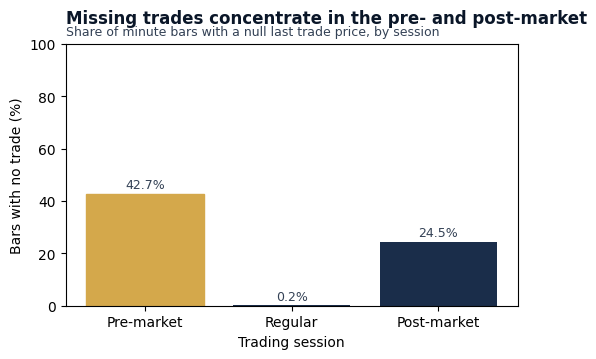

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
sessions = session_nulls["session"].to_list()
null_pct = (session_nulls["null_rate"] * 100).to_numpy()
bars = ax.bar(sessions, null_pct, color=COLORS["slate"])
bars[null_pct.argmax()].set_color(COLORS["amber"])
for x, v in zip(sessions, null_pct):
    ax.text(x, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=COLORS["neutral"])
ax.set_ylabel("Bars with no trade (%)")
ax.set_xlabel("Trading session")
ax.set_ylim(0, 100)
add_message_title(
    ax,
    "Missing trades concentrate in the pre- and post-market",
    subtitle="Share of minute bars with a null last trade price, by session",
)
plt.show()

## 4. Data Quality: OHLC Invariants

Trade OHLC must satisfy invariants: High ≥ Low, High ≥ Open/Close, Low ≤ Open/Close.

In [16]:
# OHLC invariants (trade prices)
invariants = check_ohlc_invariants(
    df,
    open_col="first_trade_price",
    high_col="high_trade_price",
    low_col="low_trade_price",
    close_col="last_trade_price",
    volume_col="volume",
)

print("=== OHLC Invariants (Trade Prices) ===")
for row in invariants.iter_rows(named=True):
    status = "[OK]" if row["valid_pct"] >= 99.99 else "[WARN]"
    print(f"  {status} {row['check']}: {row['valid_pct']:.2f}%")

=== OHLC Invariants (Trade Prices) ===
  [OK] high_gte_low: 100.00%
  [OK] high_gte_open: 100.00%
  [OK] high_gte_close: 100.00%
  [OK] low_lte_open: 100.00%
  [OK] low_lte_close: 100.00%
  [OK] volume_non_negative: 100.00%


## 5. Quote OHLC: NBBO Dynamics

Quote fields capture the National Best Bid and Offer (NBBO) at key moments:

| Field Pattern | Meaning |
|--------------|---------|
| `open_bid/ask_price` | NBBO at bar start (carried forward if no change) |
| `high_bid/ask_price` | Highest bid/ask during the bar |
| `low_bid/ask_price` | Lowest bid/ask during the bar |
| `close_bid/ask_price` | NBBO at bar end |

Quote fields are **never null** because NBBO is always defined (carried forward).

In [17]:
# Quote price statistics
quote_stats = df.select(
    [
        pl.col("open_bid_price").mean().alias("avg_bid"),
        pl.col("open_ask_price").mean().alias("avg_ask"),
        (pl.col("open_ask_price") - pl.col("open_bid_price")).mean().alias("avg_spread"),
        pl.col("open_bid_size").mean().alias("avg_bid_size"),
        pl.col("open_ask_size").mean().alias("avg_ask_size"),
    ]
)

print("=== Quote Statistics ===")
print(quote_stats)

=== Quote Statistics ===
shape: (1, 5)
┌────────────┬────────────┬────────────┬──────────────┬──────────────┐
│ avg_bid    ┆ avg_ask    ┆ avg_spread ┆ avg_bid_size ┆ avg_ask_size │
│ ---        ┆ ---        ┆ ---        ┆ ---          ┆ ---          │
│ f64        ┆ f64        ┆ f64        ┆ f64          ┆ f64          │
╞════════════╪════════════╪════════════╪══════════════╪══════════════╡
│ 879.556099 ┆ 881.956475 ┆ 2.394051   ┆ 342.588836   ┆ 357.711015   │
└────────────┴────────────┴────────────┴──────────────┴──────────────┘


In [18]:
# Compute midpoint and spread in basis points
df = df.with_columns(
    ((pl.col("open_bid_price") + pl.col("open_ask_price")) / 2).alias("mid_price"),
)
df = df.with_columns(
    pl.when(pl.col("mid_price") > 0)
    .then((pl.col("open_ask_price") - pl.col("open_bid_price")) / pl.col("mid_price") * 10_000)
    .otherwise(None)
    .alias("spread_bps"),
)

The spread distribution is heavy-tailed, so an ECDF reads better than a histogram:
most bars sit at a few basis points, with a long tail from illiquid extended-hours bars.

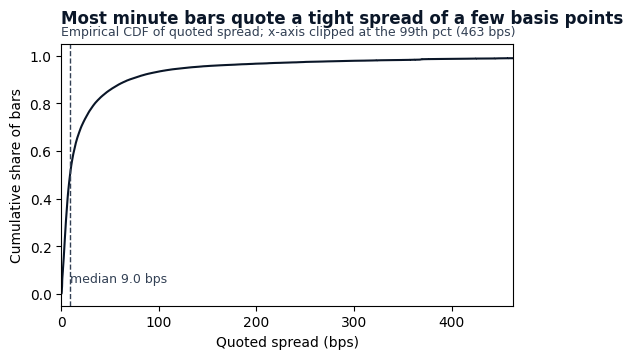

In [19]:
spread = df.select(pl.col("spread_bps").drop_nulls().drop_nans()).to_series().to_numpy()
p99 = np.quantile(spread, 0.99)
spread_sorted = np.sort(spread)
ecdf = np.arange(1, len(spread_sorted) + 1) / len(spread_sorted)
median = float(np.median(spread))

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(spread_sorted, ecdf, color=COLORS["blue"], linewidth=1.5)
ax.axvline(median, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax.text(median, 0.05, f"median {median:.1f} bps", color=COLORS["neutral"], fontsize=9)
ax.set_xlim(0, p99)
ax.set_xlabel("Quoted spread (bps)")
ax.set_ylabel("Cumulative share of bars")
add_message_title(
    ax,
    "Most minute bars quote a tight spread of a few basis points",
    subtitle=f"Empirical CDF of quoted spread; x-axis clipped at the 99th pct ({p99:.0f} bps)",
)
plt.show()

## 6. Trade OHLC: Actual Executions

Trade fields capture actual executed trades, which may differ from quotes:

| Field | Meaning |
|-------|---------|
| `first_trade_price/size/time` | First trade of the minute |
| `high_trade_price/size/time` | Trade at highest price |
| `low_trade_price/size/time` | Trade at lowest price |
| `last_trade_price/size/time` | Final trade of the minute |

Trade fields are **null when no trades occur** in the bar (common in extended hours).

In [20]:
# Trade statistics (excluding nulls)
trade_stats = df.filter(pl.col("last_trade_price").is_not_null()).select(
    [
        pl.col("first_trade_price").mean().alias("avg_open"),
        pl.col("high_trade_price").mean().alias("avg_high"),
        pl.col("low_trade_price").mean().alias("avg_low"),
        pl.col("last_trade_price").mean().alias("avg_close"),
        pl.col("first_trade_size").mean().alias("avg_first_size"),
        pl.col("last_trade_size").mean().alias("avg_last_size"),
    ]
)

print("=== Trade Statistics (Bars With Trades) ===")
print(trade_stats)

=== Trade Statistics (Bars With Trades) ===
shape: (1, 6)
┌───────────┬────────────┬────────────┬────────────┬────────────────┬───────────────┐
│ avg_open  ┆ avg_high   ┆ avg_low    ┆ avg_close  ┆ avg_first_size ┆ avg_last_size │
│ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---            ┆ ---           │
│ f64       ┆ f64        ┆ f64        ┆ f64        ┆ f64            ┆ f64           │
╞═══════════╪════════════╪════════════╪════════════╪════════════════╪═══════════════╡
│ 894.84819 ┆ 895.445606 ┆ 894.207894 ┆ 894.846872 ┆ 562.449855     ┆ 62.95058      │
└───────────┴────────────┴────────────┴────────────┴────────────────┴───────────────┘


In [21]:
# Compare trade price to midpoint
df = df.with_columns(
    pl.when(pl.col("last_trade_price").is_not_null() & (pl.col("mid_price") > 0))
    .then((pl.col("last_trade_price") - pl.col("mid_price")) / pl.col("mid_price") * 10_000)
    .otherwise(None)
    .alias("last_trade_vs_mid_bps"),
)

print("\n=== Last Trade vs Midpoint (bps) ===")
print(
    df.filter(pl.col("last_trade_vs_mid_bps").is_not_null()).select(
        pl.col("last_trade_vs_mid_bps").quantile(0.01).alias("p1"),
        pl.col("last_trade_vs_mid_bps").quantile(0.25).alias("q25"),
        pl.col("last_trade_vs_mid_bps").median().alias("median"),
        pl.col("last_trade_vs_mid_bps").quantile(0.75).alias("q75"),
        pl.col("last_trade_vs_mid_bps").quantile(0.99).alias("p99"),
    )
)


=== Last Trade vs Midpoint (bps) ===
shape: (1, 5)
┌────────────┬───────────┬──────────┬──────────┬───────────┐
│ p1         ┆ q25       ┆ median   ┆ q75      ┆ p99       │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ f64        ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞════════════╪═══════════╪══════════╪══════════╪═══════════╡
│ -39.273356 ┆ -4.170114 ┆ 0.192474 ┆ 4.541922 ┆ 38.144169 │
└────────────┴───────────┴──────────┴──────────┴───────────┘


## 7. Trade Buckets: Aggressor Direction

Trade buckets classify each trade by execution price relative to NBBO at trade time:

| Bucket | Location | Signal |
|--------|----------|--------|
| `trade_at_bid` | At or below best bid | **Seller aggressor** (hitting bid) |
| `trade_at_bid_mid` | Between bid and mid | Seller with price improvement |
| `trade_at_mid` | At midpoint | Neutral / matched |
| `trade_at_mid_ask` | Between mid and ask | Buyer with price improvement |
| `trade_at_ask` | At or above best ask | **Buyer aggressor** (lifting offer) |
| `trade_at_cross` | Crossed/locked market | Exclude from imbalance (anomaly) |

### Why This Matters

The **aggressor** is the party crossing the spread to trade immediately. Tracking
aggressor flow reveals **informed vs uninformed order flow patterns**:

- **High trade_at_ask**: Buyers are aggressive → bullish pressure
- **High trade_at_bid**: Sellers are aggressive → bearish pressure

> **Price Improvement**: When a seller executes between bid and mid, they received
> more than the bid price. When a buyer executes between mid and ask, they paid
> less than the ask. This often indicates off-exchange matching or hidden liquidity.

The `trade_at_cross` bucket corresponds to locked/crossed markets where bid ≥ ask.
These are excluded from imbalance calculations because aggressor direction is
undefined.

In [22]:
# Trade bucket statistics
bucket_cols = [
    "trade_at_bid",
    "trade_at_bid_mid",
    "trade_at_mid",
    "trade_at_mid_ask",
    "trade_at_ask",
    "trade_at_cross",
]
available_buckets = [c for c in bucket_cols if c in df.columns]

if available_buckets:
    bucket_stats = df.select([pl.col(c).sum().alias(c) for c in available_buckets])
    total = sum(bucket_stats.row(0))
    bucket_pct = {c: 100 * bucket_stats[c][0] / total for c in available_buckets}

Charting the buckets from seller-aggressive (at bid) to buyer-aggressive (at ask) shows
how volume splits across the spread. A near-symmetric split around the midpoint is the
baseline; a persistent tilt toward the ask or the bid is the tradable signal.

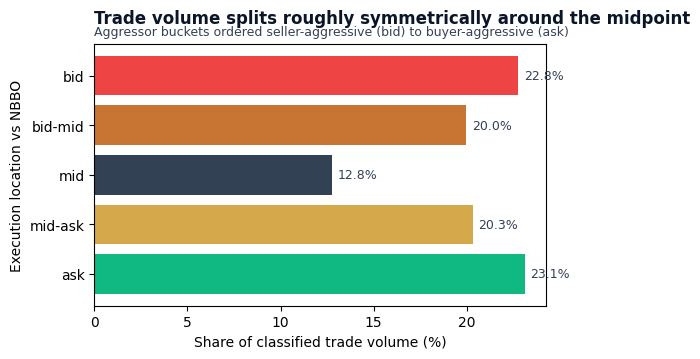

In [23]:
order = ["trade_at_bid", "trade_at_bid_mid", "trade_at_mid", "trade_at_mid_ask", "trade_at_ask"]
order = [c for c in order if c in bucket_pct]
labels = [c.replace("trade_at_", "").replace("_", "-") for c in order]
values = [bucket_pct[c] for c in order]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
colors = [
    COLORS["negative"],
    COLORS["copper"],
    COLORS["neutral"],
    COLORS["amber"],
    COLORS["positive"],
]
ax.barh(labels, values, color=colors[: len(order)])
for y, v in enumerate(values):
    ax.text(v + 0.3, y, f"{v:.1f}%", va="center", fontsize=9, color=COLORS["neutral"])
ax.set_xlabel("Share of classified trade volume (%)")
ax.set_ylabel("Execution location vs NBBO")
ax.invert_yaxis()
add_message_title(
    ax,
    "Trade volume splits roughly symmetrically around the midpoint",
    subtitle="Aggressor buckets ordered seller-aggressive (bid) to buyer-aggressive (ask)",
)
plt.show()

### Order Flow Imbalance

Aggregating the buy- and sell-aggressor buckets into a single signed ratio gives the
order flow imbalance:

$$\text{OFI} = \frac{V_\text{buy} - V_\text{sell}}{V_\text{buy} + V_\text{sell}}$$

where $V_\text{buy}$ is volume executed at or above the midpoint and $V_\text{sell}$ is
volume at or below it. OFI ranges from $-1$ (all sellers) to $+1$ (all buyers).

In [24]:
# Compute Order Flow Imbalance (OFI)
if all(
    c in df.columns
    for c in ["trade_at_bid", "trade_at_bid_mid", "trade_at_ask", "trade_at_mid_ask"]
):
    df = df.with_columns(
        (pl.col("trade_at_ask") + pl.col("trade_at_mid_ask")).alias("buy_aggressor"),
        (pl.col("trade_at_bid") + pl.col("trade_at_bid_mid")).alias("sell_aggressor"),
    )
    df = df.with_columns(
        pl.when((pl.col("buy_aggressor") + pl.col("sell_aggressor")) > 0)
        .then(
            (pl.col("buy_aggressor") - pl.col("sell_aggressor"))
            / (pl.col("buy_aggressor") + pl.col("sell_aggressor"))
        )
        .otherwise(0.0)
        .alias("order_flow_imbalance"),
    )

    print("=== Order Flow Imbalance (OFI) ===")
    print(
        df.select(
            pl.col("order_flow_imbalance").mean().alias("mean"),
            pl.col("order_flow_imbalance").std().alias("std"),
            pl.col("order_flow_imbalance").quantile(0.25).alias("q25"),
            pl.col("order_flow_imbalance").quantile(0.75).alias("q75"),
        )
    )

=== Order Flow Imbalance (OFI) ===
shape: (1, 4)
┌──────────┬──────────┬───────────┬─────────┐
│ mean     ┆ std      ┆ q25       ┆ q75     │
│ ---      ┆ ---      ┆ ---       ┆ ---     │
│ f64      ┆ f64      ┆ f64       ┆ f64     │
╞══════════╪══════════╪═══════════╪═════════╡
│ 0.003827 ┆ 0.535534 ┆ -0.254188 ┆ 0.25776 │
└──────────┴──────────┴───────────┴─────────┘


### Trading Hypotheses: OFI Momentum and Reversal

**Momentum Hypothesis**: Persistent aggressor imbalance predicts short-term price direction.

| Signal | Condition | Expected Outcome |
|--------|-----------|------------------|
| Strong Buy Pressure | OFI > 0.3 for multiple bars | Price increase |
| Strong Sell Pressure | OFI < -0.3 for multiple bars | Price decrease |

**Reversal Hypothesis**: Extreme OFI leads to short-term mean reversion.

| Signal | Condition | Expected Outcome |
|--------|-----------|------------------|
| Extreme Buying | OFI > 0.7 (exhaustion) | Potential reversal down |
| Extreme Selling | OFI < -0.7 (capitulation) | Potential reversal up |

These form the basis for the **order flow reversal strategy** developed in later chapters.

## 8. Tick Direction: Trade-Level Momentum

Tick direction tracks price movement at each trade:

| Field | Meaning |
|-------|---------|
| `uptick_volume` | Volume at prices > previous trade |
| `downtick_volume` | Volume at prices < previous trade |
| `repeat_uptick_volume` | Volume at same price after uptick |
| `repeat_downtick_volume` | Volume at same price after downtick |
| `unknown_tick_volume` | First trade of day (no prior reference) |

### Why This Matters

Tick direction captures **price momentum at the trade level**. Unlike simple returns,
this shows the actual trade-by-trade direction of price movement. An uptick ratio
persistently above 0.5 indicates buying momentum; below 0.5 indicates selling momentum.

This differs from OFI in that it measures **sequential price changes** rather than
**aggressor direction**. Both are useful but capture different aspects of order flow.

In [25]:
tick_cols = ["uptick_volume", "downtick_volume", "repeat_uptick_volume", "repeat_downtick_volume"]
if all(c in df.columns for c in tick_cols):
    df = df.with_columns(
        (
            pl.col("uptick_volume")
            + pl.col("repeat_uptick_volume")
            - pl.col("downtick_volume")
            - pl.col("repeat_downtick_volume")
        ).alias("net_uptick_volume"),
    )
    df = df.with_columns(
        pl.when(
            (
                pl.col("uptick_volume")
                + pl.col("downtick_volume")
                + pl.col("repeat_uptick_volume")
                + pl.col("repeat_downtick_volume")
            )
            > 0
        )
        .then(
            (pl.col("uptick_volume") + pl.col("repeat_uptick_volume"))
            / (
                pl.col("uptick_volume")
                + pl.col("downtick_volume")
                + pl.col("repeat_uptick_volume")
                + pl.col("repeat_downtick_volume")
            )
        )
        .otherwise(0.5)
        .alias("uptick_ratio"),
    )

    print("=== Tick Direction Statistics ===")
    print(
        df.select(
            pl.col("uptick_ratio").mean().alias("avg_uptick_ratio"),
            pl.col("uptick_ratio").std().alias("std_uptick_ratio"),
            pl.col("net_uptick_volume").mean().alias("avg_net_uptick"),
        )
    )

=== Tick Direction Statistics ===
shape: (1, 3)
┌──────────────────┬──────────────────┬────────────────┐
│ avg_uptick_ratio ┆ std_uptick_ratio ┆ avg_net_uptick │
│ ---              ┆ ---              ┆ ---            │
│ f64              ┆ f64              ┆ f64            │
╞══════════════════╪══════════════════╪════════════════╡
│ 0.492002         ┆ 0.238088         ┆ -351.718478    │
└──────────────────┴──────────────────┴────────────────┘


## 9. Pressure Indicators: Directional Intensity

Pressure fields measure how far trades execute from the midpoint:

| Field | Formula | Range |
|-------|---------|-------|
| `trade_to_mid_vol_weight` | Σ(trade_price - mid) × volume / Σ volume | Dollars |
| `trade_to_mid_vol_weight_rel` | Same, normalized by spread | Unitless |

### Why This Matters

- **Positive pressure**: Trades executing above midpoint → buying pressure
- **Negative pressure**: Trades executing below midpoint → selling pressure

The **relative** version normalizes by spread, making it comparable across stocks
with different price levels and liquidity. A relative pressure of 0.5 means trades
are on average executing halfway between the midpoint and the ask (consistent buying).

Unlike OFI which counts shares by bucket, pressure measures the **magnitude** of
price impact - how aggressively traders are pushing prices away from fair value.

In [26]:
pressure_cols = ["trade_to_mid_vol_weight", "trade_to_mid_vol_weight_rel"]
if all(c in df.columns for c in pressure_cols):
    print("=== Pressure Indicator Statistics ===")
    print(
        df.filter(pl.col("trade_to_mid_vol_weight_rel").is_not_null()).select(
            pl.col("trade_to_mid_vol_weight").mean().alias("avg_absolute"),
            pl.col("trade_to_mid_vol_weight_rel").mean().alias("avg_relative"),
            pl.col("trade_to_mid_vol_weight_rel").std().alias("std_relative"),
            pl.col("trade_to_mid_vol_weight_rel").quantile(0.10).alias("q10"),
            pl.col("trade_to_mid_vol_weight_rel").quantile(0.90).alias("q90"),
        )
    )

=== Pressure Indicator Statistics ===


shape: (1, 5)
┌──────────────┬──────────────┬──────────────┬──────────┬─────────┐
│ avg_absolute ┆ avg_relative ┆ std_relative ┆ q10      ┆ q90     │
│ ---          ┆ ---          ┆ ---          ┆ ---      ┆ ---     │
│ f64          ┆ f64          ┆ f64          ┆ f64      ┆ f64     │
╞══════════════╪══════════════╪══════════════╪══════════╪═════════╡
│ -0.590798    ┆ 0.000609     ┆ 3.25784      ┆ -0.30544 ┆ 0.31321 │
└──────────────┴──────────────┴──────────────┴──────────┴─────────┘


## 10. Volume: Exchange vs Off-Exchange (FINRA)

Volume is split between lit exchanges and off-exchange venues:

| Field | Source | Description |
|-------|--------|-------------|
| `volume` | Lit exchanges | NYSE, NASDAQ, BATS, etc. |
| `finra_volume` | Off-exchange | Dark pools, internalizers, OTC |
| `total_trades` | All | Number of trades in the bar |

**Total Volume = volume + finra_volume**

> **Data Contract**: FINRA Trade Reporting Facility (TRF) collects reports of
> off-exchange trades (dark pools, internalizers, OTC). These trades are included
> in the consolidated tape but execute away from lit exchanges.

### Why This Matters

- **High FINRA share (>40%)**: Institutional activity, larger trades seeking anonymity
- **Low FINRA share (<20%)**: Retail-dominated, smaller trades
- **FINRA spikes**: May indicate large block trades seeking minimal market impact

This can be used for **regime filtering** in trading strategies - some signals
work better in institutional vs retail regimes.

In [27]:
if "finra_volume" in df.columns:
    df = df.with_columns(
        (pl.col("volume") + pl.col("finra_volume")).alias("total_volume"),
    )
    df = df.with_columns(
        pl.when(pl.col("total_volume") > 0)
        .then(pl.col("finra_volume") / pl.col("total_volume"))
        .otherwise(0.0)
        .alias("finra_share"),
    )

    print("=== Volume Statistics ===")
    print(
        df.select(
            pl.col("volume").sum().alias("exchange_volume"),
            pl.col("finra_volume").sum().alias("finra_volume"),
            pl.col("total_volume").sum().alias("total_volume"),
            (pl.col("finra_volume").sum() / pl.col("total_volume").sum()).alias("finra_share"),
        )
    )
    # The intraday shape of the FINRA share is charted in section 14.

=== Volume Statistics ===
shape: (1, 4)
┌─────────────────┬──────────────┬──────────────┬─────────────┐
│ exchange_volume ┆ finra_volume ┆ total_volume ┆ finra_share │
│ ---             ┆ ---          ┆ ---          ┆ ---         │
│ i64             ┆ i64          ┆ i64          ┆ f64         │
╞═════════════════╪══════════════╪══════════════╪═════════════╡
│ 22754012488     ┆ 18810329541  ┆ 41564342029  ┆ 0.452559    │
└─────────────────┴──────────────┴──────────────┴─────────────┘


## 11. Spread: Liquidity Conditions

Spread fields capture bid-ask spread dynamics:

| Field | Meaning | Note |
|-------|---------|------|
| `min_spread` | Minimum spread during bar | **0 = locked/crossed market** |
| `max_spread` | Maximum spread during bar | Widening indicates stress |

**min_spread = 0 is an anomaly indicator**, not "free liquidity." It signals
market stress where bid ≥ ask (locked or crossed market).

In [28]:
if "min_spread" in df.columns:
    # Spread statistics
    print("=== Spread Statistics ===")
    print(
        df.select(
            pl.col("min_spread").mean().alias("avg_min_spread"),
            pl.col("max_spread").mean().alias("avg_max_spread"),
            (pl.col("min_spread") == 0).mean().alias("locked_market_rate"),
        )
    )
    # The intraday spread curve is charted in section 14.

=== Spread Statistics ===


shape: (1, 3)
┌────────────────┬────────────────┬────────────────────┐
│ avg_min_spread ┆ avg_max_spread ┆ locked_market_rate │
│ ---            ┆ ---            ┆ ---                │
│ f64            ┆ f64            ┆ f64                │
╞════════════════╪════════════════╪════════════════════╡
│ 2.023088       ┆ 3.118234       ┆ 0.0                │
└────────────────┴────────────────┴────────────────────┘


## 12. VWAP and Time-Weighted Prices

| Field | Meaning |
|-------|---------|
| `vwap` | Volume-weighted average price (exchange trades) |
| `finra_vwap` | VWAP of off-exchange trades |
| `time_weight_bid` | Time-weighted average bid |
| `time_weight_ask` | Time-weighted average ask |

In [29]:
vwap_cols = ["vwap", "finra_vwap", "time_weight_bid", "time_weight_ask"]
available_vwap = [c for c in vwap_cols if c in df.columns]

if available_vwap:
    print("=== VWAP and Time-Weighted Prices ===")
    for col in available_vwap:
        non_null = df.filter(pl.col(col).is_not_null())
        if len(non_null) > 0:
            avg = non_null[col].mean()
            null_pct = 100 * (len(df) - len(non_null)) / len(df)
            if avg is not None:
                print(f"  {col}: avg=${avg:.2f}, {null_pct:.1f}% null")
            else:
                print(f"  {col}: no valid values, {null_pct:.1f}% null")
        else:
            print(f"  {col}: all null")
else:
    print("=== VWAP columns not present in this dataset ===")

=== VWAP and Time-Weighted Prices ===


  vwap: avg=$897.34, 22.9% null


  finra_vwap: avg=$881.62, 39.0% null
  time_weight_bid: avg=$879.55, 0.0% null
  time_weight_ask: avg=$881.96, 0.0% null


## 13. Visualizations: Single Day Deep Dive

In [30]:
# Pick highest-volume symbol and day
vol_col = "total_volume" if "total_volume" in df.columns else "volume"

top_symbol = (
    df.group_by("symbol")
    .agg(pl.col(vol_col).sum().alias("tv"))
    .sort("tv", descending=True)
    .select("symbol")
    .row(0)[0]
)

top_day = (
    df.filter(pl.col("symbol") == top_symbol)
    .with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
    .group_by("timestamp")
    .agg(pl.col(vol_col).sum().alias("day_vol"))
    .sort("day_vol", descending=True)
    .select("timestamp")
    .row(0)[0]
)

df_day = (
    df.filter(pl.col("symbol") == top_symbol)
    .filter(pl.col("timestamp").dt.date() == pl.lit(top_day))
    .sort("timestamp")
)

print(f"=== Deep Dive: {top_symbol} on {top_day} ({df_day.height:,} bars) ===")

=== Deep Dive: AAPL on 2020-09-04 (960 bars) ===


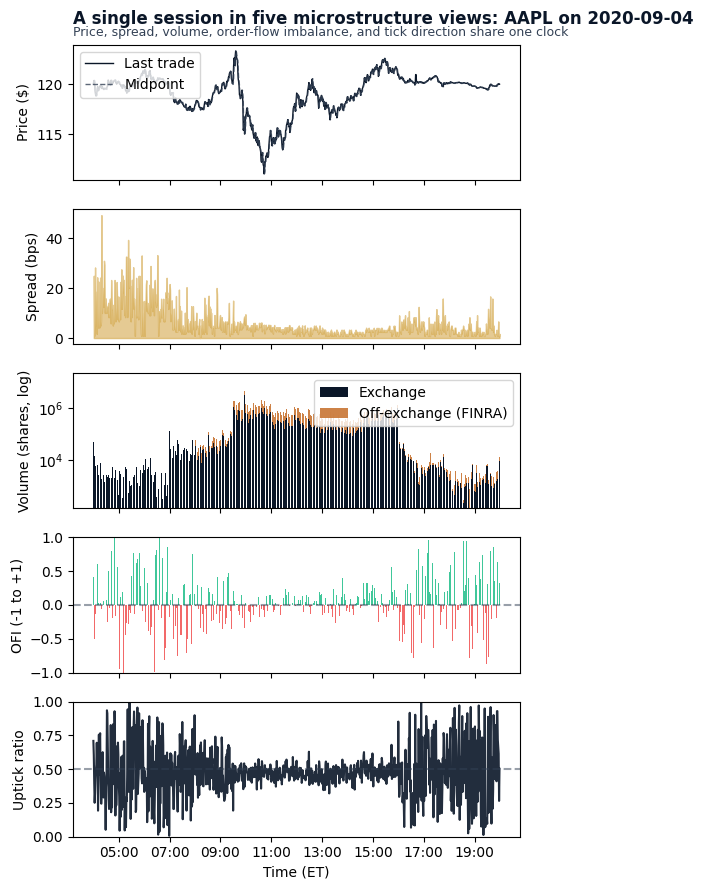

In [31]:
# Multi-panel microstructure dashboard: one row per mechanism, shared time axis
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(FIGSIZE["single"][0], 9), sharex=True)

ts = df_day["timestamp"].to_numpy()

# Panel 1: Price vs midpoint
if "last_trade_price" in df_day.columns:
    axes[0].plot(
        ts,
        df_day["last_trade_price"].to_numpy(),
        color=COLORS["blue"],
        linewidth=1,
        label="Last trade",
    )
if "mid_price" in df_day.columns:
    axes[0].plot(
        ts,
        df_day["mid_price"].to_numpy(),
        color=COLORS["neutral"],
        alpha=0.8,
        linewidth=1,
        linestyle="--",
        label="Midpoint",
    )
axes[0].set_ylabel("Price ($)")
axes[0].legend(loc="upper left")
add_message_title(
    axes[0],
    f"A single session in five microstructure views: {top_symbol} on {top_day}",
    subtitle="Price, spread, volume, order-flow imbalance, and tick direction share one clock",
)

# Panel 2: Spread
if "spread_bps" in df_day.columns:
    axes[1].fill_between(ts, df_day["spread_bps"].to_numpy(), color=COLORS["amber"], alpha=0.6)
    axes[1].set_ylabel("Spread (bps)")

# Panel 3: Volume (exchange vs off-exchange)
if "volume" in df_day.columns and "finra_volume" in df_day.columns:
    axes[2].bar(
        ts, df_day["volume"].to_numpy(), width=0.0005, label="Exchange", color=COLORS["blue"]
    )
    axes[2].bar(
        ts,
        df_day["finra_volume"].to_numpy(),
        width=0.0005,
        bottom=df_day["volume"].to_numpy(),
        label="Off-exchange (FINRA)",
        color=COLORS["copper"],
        alpha=0.9,
    )
    axes[2].set_ylabel("Volume (shares, log)")
    axes[2].set_yscale("log")
    axes[2].legend(loc="upper right")

# Panel 4: OFI (green when buyers dominate, red when sellers do)
if "order_flow_imbalance" in df_day.columns:
    ofi = df_day["order_flow_imbalance"].to_numpy()
    bar_colors = [COLORS["positive"] if x > 0 else COLORS["negative"] for x in ofi]
    axes[3].bar(ts, ofi, width=0.0005, color=bar_colors, alpha=0.8)
    axes[3].set_ylabel("OFI (-1 to +1)")
    axes[3].axhline(y=0, color=COLORS["neutral"], linestyle="--", alpha=0.5)
    axes[3].set_ylim(-1, 1)

# Panel 5: Uptick ratio
if "uptick_ratio" in df_day.columns:
    axes[4].plot(ts, df_day["uptick_ratio"].to_numpy(), color=COLORS["blue"], alpha=0.9)
    axes[4].set_ylabel("Uptick ratio")
    axes[4].axhline(y=0.5, color=COLORS["neutral"], linestyle="--", alpha=0.5)
    axes[4].set_ylim(0, 1)
    axes[4].set_xlabel("Time (ET)")

# Single session: label the shared x-axis every 2 hours as HH:MM (sharex propagates to all panels)
axes[4].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

## 14. Intraday Patterns

Key microstructure metrics show distinct patterns across the trading day.

In [32]:
# Compute hourly averages for RTH (9:30-16:00)
df_rth_hours = (
    df.filter((pl.col("timestamp").dt.hour() >= 10) & (pl.col("timestamp").dt.hour() < 16))
    .with_columns(pl.col("timestamp").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(
        pl.col("spread_bps").mean().alias("avg_spread"),
        pl.col("volume").sum().alias("total_volume"),
        pl.col("finra_share").mean().alias("avg_finra_share")
        if "finra_share" in df.columns
        else pl.lit(0).alias("avg_finra_share"),
        pl.col("order_flow_imbalance").std().alias("ofi_volatility")
        if "order_flow_imbalance" in df.columns
        else pl.lit(0).alias("ofi_volatility"),
    )
    .sort("hour")
)

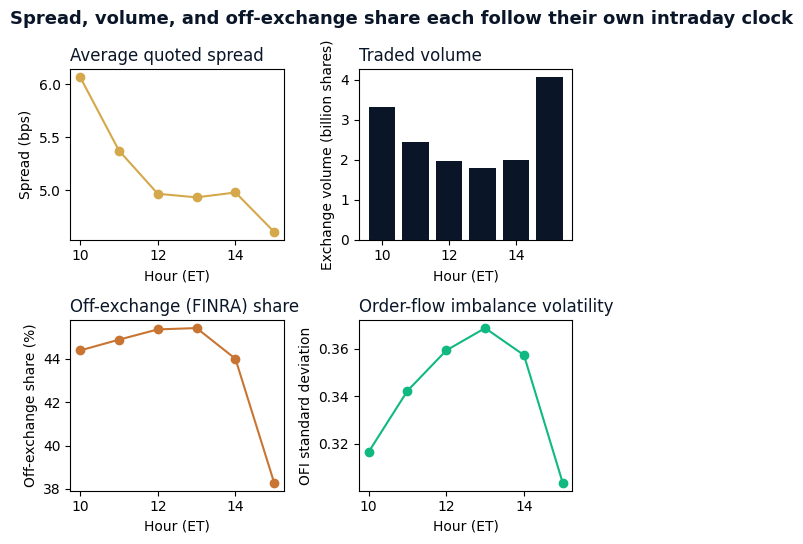

In [33]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE["dashboard_2x2"])

hours = df_rth_hours["hour"].to_numpy()

# Spread pattern
axes[0, 0].plot(hours, df_rth_hours["avg_spread"].to_numpy(), marker="o", color=COLORS["amber"])
axes[0, 0].set_xlabel("Hour (ET)")
axes[0, 0].set_ylabel("Spread (bps)")
axes[0, 0].set_title("Average quoted spread", loc="left", color=COLORS["blue"])

# Volume pattern
axes[0, 1].bar(hours, df_rth_hours["total_volume"].to_numpy() / 1e9, color=COLORS["blue"])
axes[0, 1].set_xlabel("Hour (ET)")
axes[0, 1].set_ylabel("Exchange volume (billion shares)")
axes[0, 1].set_title("Traded volume", loc="left", color=COLORS["blue"])

# FINRA share pattern
if "finra_share" in df.columns:
    axes[1, 0].plot(
        hours, df_rth_hours["avg_finra_share"].to_numpy() * 100, marker="o", color=COLORS["copper"]
    )
    axes[1, 0].set_xlabel("Hour (ET)")
    axes[1, 0].set_ylabel("Off-exchange share (%)")
    axes[1, 0].set_title("Off-exchange (FINRA) share", loc="left", color=COLORS["blue"])

# OFI volatility pattern
if "order_flow_imbalance" in df.columns:
    axes[1, 1].plot(
        hours, df_rth_hours["ofi_volatility"].to_numpy(), marker="o", color=COLORS["positive"]
    )
    axes[1, 1].set_xlabel("Hour (ET)")
    axes[1, 1].set_ylabel("OFI standard deviation")
    axes[1, 1].set_title("Order-flow imbalance volatility", loc="left", color=COLORS["blue"])

fig.suptitle(
    "Spread, volume, and off-exchange share each follow their own intraday clock",
    x=0.01,
    ha="left",
    fontsize=13,
    color=COLORS["blue"],
    fontweight="semibold",
)
plt.tight_layout()
plt.show()

## 15. Trading Mechanism Menu: Connecting Fields to Strategies

The microstructure fields in TAQ minute bars connect to specific trading mechanisms:

### Intraday Momentum / Trend Persistence

**Features**: `order_flow_imbalance`, `uptick_ratio`, `trade_to_mid_vol_weight`

| Signal | Condition | Strategy |
|--------|-----------|----------|
| OFI > 0.3 for 5+ bars | Persistent buying | Follow momentum |
| Uptick ratio > 0.6 | Price trending up | Hold long positions |
| Positive pressure consistent | Aggressive buying | Continuation expected |

### Liquidity Shock / Spread Widening

**Features**: `spread_bps`, `nbbo_quote_count`, `min_spread`

| Signal | Condition | Strategy |
|--------|-----------|----------|
| Spread > 2× rolling mean | Liquidity withdrawal | Reduce position size |
| min_spread = 0 | Locked/crossed market | Fast market, pause trading |
| Quote count drop | Market makers stepping back | Increase execution urgency |

### Hidden Liquidity / Institutional Regime

**Features**: `finra_share`, `finra_volume`

| Signal | Condition | Strategy |
|--------|-----------|----------|
| FINRA share > 40% | Institutional activity | Larger moves possible |
| FINRA spike vs previous bars | Block trade | Watch for continuation |
| FINRA share < 20% | Retail-dominated | Mean reversion may work |

### Mean Reversion / Exhaustion

**Features**: `order_flow_imbalance` (extreme values)

| Signal | Condition | Strategy |
|--------|-----------|----------|
| OFI > 0.7 | Extreme buying (exhaustion) | Fade the move |
| OFI < -0.7 | Extreme selling (capitulation) | Buy the dip |

> These mechanisms form the foundation for the **order flow reversal strategy**
> developed in Chapters 7-12, which transforms these raw fields into predictive
> alpha factors.

## Key Takeaways

### Dataset Structure

1. **61 columns** organized into 7 families: identifiers, quote OHLC, trade OHLC,
   spread, volume, trade buckets, and pressure indicators
2. **Continuous bars**: Rows exist for every minute 04:00-20:00 ET, even without trades
3. **Null semantics**: Trade fields null = no trades (normal), quote fields never null

### Quote vs Trade Fields

| Aspect | Quote Fields | Trade Fields |
|--------|--------------|--------------|
| Source | NBBO updates | Actual executions |
| Null when | Never (carried forward) | No trades in bar |
| Examples | open_bid_price, close_ask_price | first_trade_price, vwap |

### TAQ Field Families and Trading Mechanisms

| Family | Key Fields | Trading Mechanism |
|--------|------------|-------------------|
| **Trade Buckets** | trade_at_bid/ask | Aggressor direction → OFI |
| **Tick Direction** | uptick/downtick_volume | Trade-level momentum |
| **Pressure** | trade_to_mid_vol_weight | Directional intensity |
| **FINRA** | finra_volume | Institutional activity |
| **Spread** | min/max_spread | Liquidity conditions |

### Key Microstructure Insights

1. **Order Flow Imbalance** (OFI): Measures aggressor direction (-1 to +1)
   - Persistent OFI predicts short-term momentum
   - Extreme OFI (>0.7 or <-0.7) signals potential reversal
2. **FINRA Share**: ~45% of volume is off-exchange (institutional activity)
3. **Spread Dynamics**: Wider at open/close, tightest midday
4. **Locked Markets**: min_spread=0 indicates stress (rare but important)

### Why AlgoSeek TAQ is Valuable

- **Pre-computed from tick data**: Saves significant processing time
- **Rich semantics**: Goes beyond OHLCV with aggressor, pressure, FINRA fields
- **ML-ready**: Fields can be used directly as features or as building blocks

### Chapter 3 vs Chapter 8 Scope

| This Notebook (Ch3) | Chapter 8 Notebooks |
|---------------------|---------------------|
| Understand field meanings | Engineer predictive alpha factors |
| Data quality and semantics | Kyle's Lambda, Amihud, VPIN |
| Trading mechanisms explained | Feature selection and orthogonalization |

### Next Steps

- **Ch3 `11_algoseek_taq_eda`**: TAQ tick-level data exploration
- **Ch8 `08_financial_features/02_microstructure_features`**: Engineer alpha factors
  (Kyle's Lambda, VPIN)
- **Ch9**: Evaluate feature predictive power
- **Ch12**: Build ML models using microstructure features